## 1. 因子概述

本项目首先围绕成交额、动量趋势、滚动回归系数和波动率结构等具有明确经济含义的基础方向构建候选特征空间。在此基础上，使用大语言模型（LLM）理解不同信号的经济逻辑、适用场景和潜在互补关系，自动生成复合因子公式；随后通过遗传杂交、变异及多种自动化组合方法持续扩展候选因子，并按照赛题规定的覆盖率、IC、ICIR、StressIR、风格剔除及相关性约束进行筛选和研判，最终得到表现较优且具有可解释性的因子结果。

当前因子由六个相互补充的量价、日内路径和盘口信号构成。各组件先在当日股票池内进行缺失值处理、3σ 截尾和截面 z-score，再以固定非负权重进行线性集成：
$$
F_{i,t}=\sum_{k=1}^{6}w_k Z_{i,t}^{(k)},
\qquad w_k=\frac{1}{6}.
$$

六个组件分别为：

| 组件 | 核心统计方法 | 经济逻辑 |
|---|---|---|
| `amt_contr` | 5日与20日成交额均值之比取负 | 识别近期成交额收缩、交易拥挤度下降或筹码趋稳 |
| `tm01` | 20日日内路径效率均值 | 识别净价格移动相对于盘中往返波动更强的股票 |
| `alpha` | 隔夜反转、振幅冲击、极端收益反转与五档盘口信号复合 | 同时描述价格异常修复和盘口供需压力 |
| `tm06` | 波动归一化尾盘反转与低波动率波动交叉 | 寻找尾盘反转明确且波动状态较稳定的股票 |
| `mom20_vol` | 20日动量除以20日实现波动率 | 衡量单位风险下的中期趋势强度 |
| `park_low` | 10日与60日 Parkinson 波动代理之比取负 | 识别短期波动相对长期基准收缩的股票 |

该因子主要利用AI 来进行**候选公式的自动生成、遗传优化和机器化研判**等过程

## 2. AI 技术应用的关键环节

### 2.1 基础因子方向与经济逻辑约束

候选空间建立在以下基础因子方向之上：

- **成交额与流动性结构**：研究近期成交额相对于历史基准的扩张或收缩，以及交易活跃度变化；
- **动量与趋势结构**：研究不同观察窗口下价格趋势的持续、加速、衰减和反转；
- **滚动回归系数**：通过滚动回归描述价格、成交量、波动率或盘口信号之间随时间变化的敏感度；
- **波动率结构**：研究短期与长期波动率、上行与下行波动、波动率的波动以及日内路径特征；
- **盘口与日内路径**：研究五档买卖盘压力、价差、尾盘价格行为和价格移动效率。

这些方向为 LLM 提供了明确的字段白名单、经济逻辑边界和组合语义，使生成过程始终围绕可解释的市场机制。

### 2.2 LLM 因子合成

本项目使用 LLM 对基础方向进行组合推理和公式生成。LLM 在研究阶段承担以下任务：

1. 根据可用分钟行情、盘口和日频派生字段提出候选经济假设；
2. 判断成交额、趋势、滚动回归和波动率等信号之间可能存在的互补或条件关系；
3. 将经济假设转换为带有滚动窗口、标准化、条件结构和交叉项的候选公式；
4. 为候选公式生成经济逻辑说明并解释预期方向；
5. 检查公式所需字段、时间方向和基础可执行性；
6. 将通过基础检查的候选送入遗传进化与统一评估流程。

LLM 的作用主要体现在因子表达式的生成和重组，因子值由LLM生成的确定性代码根据平台数据自动计算。

### 2.3 遗传杂交与自动变异

通过基础检查的候选因子进入遗传进化阶段后，系统使用多种自动化操作扩展搜索空间：

1. **杂交（crossover）**：选择来自不同经济方向的父因子，将有效子结构通过加权、标准化或交互项进行组合；
2. **变异（mutation）**：调整滚动窗口、平滑方式、符号方向、归一化方法或条件阈值；
3. **方向内竞争**：在成交额、趋势、滚动回归、波动率和盘口等方向内分别保留有价值的变异，避免单一高分方向挤压其他方向；
4. **跨方向组合**：允许不同经济方向继续杂交，以发现具有增量信息的复合信号；
5. **死亡线淘汰**：覆盖率、有效交易日、IC、ICIR或压力表现不满足最低标准的候选被自动淘汰；
6. **相关性控制**：对高度相关的候选进行去重，减少公式微调造成的重复因子。

遗传算法负责系统化探索大量公式变体，LLM提供经济逻辑约束和新的候选结构。二者结合形成“LLM生成与解释、遗传算法搜索与优化、统一评估器筛选”的自动化流程。

### 2.4 自动化特征工程

代码将平台提供的一分钟行情和盘口数据自动转换为日频特征，主要包括：

- 分钟收益率及日内实现波动率；
- 开盘至决策时点的净收益和价格路径长度；
- 当日最高价、最低价、VWAP和收盘位置；
- 五档盘口加权不平衡与买卖价差置信度；
- 跨日动量、成交额均线和 Parkinson 波动率结构。

这些特征由统一代码自动计算。

### 2.5 按赛题要求筛选与研判

LLM生成的候选因子按照赛题指标进行筛选与研判。

自动筛选流程包含：

1. 覆盖率和有效交易日检查；
2. BARRA 风格及行业残差化后的 IC、ICIR 和 StressIR；
3. 不同时间子区间的稳定性检查；
4. 候选因子值的相关性去重；
5. 冻结公式和权重后进行独立留出验证；
6. 综合统计成绩、经济逻辑和跨期稳定性判断候选是否进入最终因子池。

### 2.6 线性集成与部署

每个成分因子在当日截面内进行预处理：

1. 对齐历史时点股票池；
2. 缺失值按既定规则处理；
3. 使用截面均值和样本标准差进行3σ截尾；
4. 使用截尾前的均值和标准差进行 z-score；
5. 按冻结权重线性求和。

部署 Notebook 使用确定性代码以确保：

- 同一输入得到确定性输出；
- 不依赖外部网络和外部数据；
- 平台能够直接复现因子；
- AI 研究过程与线上因子计算过程相互分离。

## 3. 六个组件的实现说明

### 3.1 成交额收缩

$$
amt\_contr=-\frac{MA_5(amount)}{MA_{20}(amount)+\epsilon}.
$$

代码实现环节：对每日成交额按股票进行5日和20日滚动均值，再计算相对收缩程度。

### 3.2 日内路径效率

$$
PathEfficiency_t=
\frac{|Close_t/Open_t-1|}
{\sum_m|r_{t,m}|+\epsilon},
\qquad
tm01=MA_{20}(PathEfficiency).
$$

分子衡量日内净移动，分母衡量实际走过的价格路径。净移动较大而往返较少时，路径效率较高。

### 3.3 双支柱信号

价格支柱由隔夜跳空反转、异常振幅反转和极端五日收益反转构成；盘口支柱由五档深度不平衡、价差置信度、VWAP偏离和收盘位置构成。两个支柱经截面标准化后组合，并在短期波动显著高于长期基准时降低权重。

### 3.4 尾盘反转与低波动率波动

$$
L_t=-\frac{LateRet_{30,t}}{STD_{20}(LateRet_{30})+\epsilon},
\qquad
R_t=-STD_5(RVSession),
$$

$$
tm06=\frac{Z_{20}(L_t)+Z_{20}(R_t)}{2}.
$$

该组件尝试识别尾盘价格冲击后的反转机会，并使用波动状态稳定性降低噪声。

### 3.5 波动率调整动量

$$
mom20\_vol=
\frac{Close_t/Close_{t-20}-1}
{STD_{20}(Ret_{1d})\sqrt{20}+\epsilon}.
$$

该组件衡量单位波动风险对应的20日趋势强度。

### 3.6 相对低波动

$$
Parkinson_{1d}=\ln(High/Low),
\qquad
park\_low=-\frac{MA_{10}(Parkinson_{1d})}
{MA_{60}(Parkinson_{1d})+\epsilon}.
$$

该组件选择短期波动低于自身长期水平的股票。



In [3]:
def main(datasources, start_date, end_date):
    """
    参数:
        datasources (dict): {"bar1m": 分钟K线表(含5档盘口), "financial": 财务表}
        start_date (str): 如 '2025-01-01 00:00:00'
        end_date (str):   如 '2026-05-26 23:59:59'

    返回:
        pd.DataFrame: ['date', 'instrument', 'factor'], 无 inf
    """
    import numpy as np
    import pandas as pd
    import dai

    bar1m = datasources["bar1m"]
    eps = 1e-9
    evaluation_start = pd.to_datetime(start_date)
    evaluation_end = pd.to_datetime(end_date)
    # 组件最大 warmup: tm06 需 120 天, 统一取 150 天
    query_start = evaluation_start - pd.Timedelta(days=150)

    NAMES = ["amt_contr", "tm01", "alpha", "tm06", "mom20_vol", "park_low"]
    WEIGHTS = {n: 1.0 / len(NAMES) for n in NAMES}   # 固定等权: 不引入权重估计误差, 降低集成方差

    # ==========================================================================
    # 0. 股票池 (日频成分, 供分区裁剪 + 最终对齐)
    # ==========================================================================
    stk_pool = dai.query(
        "SELECT date, instrument FROM bigalpha_2026_instruments",
        filters={"date": [query_start.strftime("%Y-%m-%d %H:%M:%S"), end_date]},
        compression=True,
    ).df()
    stk_pool["date"] = pd.to_datetime(stk_pool["date"], errors="coerce").dt.normalize()
    stk_pool["instrument"] = stk_pool["instrument"].astype(str)
    stk_pool = stk_pool.drop_duplicates(["date", "instrument"])
    pool_instruments = sorted(stk_pool["instrument"].unique().tolist())

    def query_chunks(sql, chunk_days=30):
        """分块查询 (instrument 分区裁剪, 全市场分钟表上约提速 30 倍)。"""
        parts = []
        cs = query_start.normalize()
        while cs <= evaluation_end:
            nxt = cs + pd.Timedelta(days=chunk_days)
            ce = min(nxt - pd.Timedelta(seconds=1), evaluation_end)
            part = dai.query(
                sql,
                filters={"date": [cs.strftime("%Y-%m-%d %H:%M:%S"),
                                  ce.strftime("%Y-%m-%d %H:%M:%S")],
                         "instrument": pool_instruments},
                compression=True,
            ).df()
            if not part.empty:
                parts.append(part)
            cs = nxt
        return pd.concat(parts, ignore_index=True) if parts else pd.DataFrame()

    def rolling_mean(d, column, window, min_periods):
        return d.groupby("instrument", sort=False)[column].transform(
            lambda v: v.rolling(window, min_periods=min_periods).mean())

    def rolling_std(d, column, window, min_periods):
        return d.groupby("instrument", sort=False)[column].transform(
            lambda v: v.rolling(window, min_periods=min_periods).std())

    def align_pool(comp):
        """组件 (date,instrument,factor) 对齐到评估窗口股票池: 日中位数填充 + 0 兜底。"""
        pool_win = stk_pool[(stk_pool["date"] >= evaluation_start.normalize())
                            & (stk_pool["date"] <= evaluation_end)]
        out = pd.merge(pool_win, comp, how="left", on=["date", "instrument"])
        out["factor"] = out.groupby("date")["factor"].transform(
            lambda v: v.fillna(v.median()))
        out["factor"] = out["factor"].fillna(0.0)
        return out

    # ==========================================================================
    # 1. SQL_A: 分钟 → 日聚合 (alpha 双支柱 + amt_contr + mom20_vol 的原料)
    # ==========================================================================
    sql_daily = f"""
    WITH daily_agg AS (
        SELECT instrument, strftime(date, '%Y-%m-%d') AS trading_day,
            FIRST(open ORDER BY date) AS open, MAX(high) AS high, MIN(low) AS low,
            LAST(close ORDER BY date) AS close, SUM(volume) AS volume, SUM(amount) AS amount,
            SUM(close * volume) / NULLIF(SUM(volume), 0) AS vwap,
            LAST(ask_price1 ORDER BY date) AS ask_p1, LAST(bid_price1 ORDER BY date) AS bid_p1,
            LAST(ask_volume1 ORDER BY date) AS ask_v1, LAST(bid_volume1 ORDER BY date) AS bid_v1,
            LAST(ask_volume2 ORDER BY date) AS ask_v2, LAST(bid_volume2 ORDER BY date) AS bid_v2,
            LAST(ask_volume3 ORDER BY date) AS ask_v3, LAST(bid_volume3 ORDER BY date) AS bid_v3,
            LAST(ask_volume4 ORDER BY date) AS ask_v4, LAST(bid_volume4 ORDER BY date) AS bid_v4,
            LAST(ask_volume5 ORDER BY date) AS ask_v5, LAST(bid_volume5 ORDER BY date) AS bid_v5,
            LN(MAX(high) / NULLIF(MIN(low), 0)) AS parkinson_1d
        FROM {bar1m} WHERE ask_price1 > 0 AND bid_price1 > 0
        GROUP BY instrument, strftime(date, '%Y-%m-%d')
    ),
    daily_features AS (
        SELECT *,
            COALESCE(close / NULLIF(LAG(close, 1) OVER w, 0) - 1, 0) AS ret_1d,
            COALESCE(close / NULLIF(LAG(close, 5) OVER w, 0) - 1, 0) AS ret_5d,
            (high - low) / NULLIF(close, 0) AS amplitude,
            AVG((high - low) / NULLIF(close, 0)) OVER (
                PARTITION BY instrument ORDER BY trading_day ROWS BETWEEN 5 PRECEDING AND 1 PRECEDING
            ) AS amp_ma5,
            AVG(parkinson_1d) OVER (
                PARTITION BY instrument ORDER BY trading_day ROWS BETWEEN 9 PRECEDING AND CURRENT ROW
            ) AS parkinson_10d,
            AVG(parkinson_1d) OVER (
                PARTITION BY instrument ORDER BY trading_day ROWS BETWEEN 59 PRECEDING AND CURRENT ROW
            ) AS parkinson_60d
        FROM daily_agg WINDOW w AS (PARTITION BY instrument ORDER BY trading_day)
    )
    SELECT CAST(trading_day AS DATETIME) AS date, instrument,
        open, close, amount,
        open / NULLIF(LAG(close, 1) OVER (PARTITION BY instrument ORDER BY trading_day), 0) - 1.0 AS d1_overnight_gap,
        amplitude, amp_ma5, ret_1d, ret_5d,
        ask_v1, bid_v1, ask_v2, bid_v2, ask_v3, bid_v3, ask_v4, bid_v4, ask_v5, bid_v5,
        ask_p1, bid_p1, (ask_p1 - bid_p1) / NULLIF((ask_p1 + bid_p1) / 2.0, 0) AS relative_spread,
        close / NULLIF(vwap, 0) - 1.0 AS close_vs_vwap,
        (close - low) / NULLIF(high - low, 0) AS close_position,
        parkinson_10d / NULLIF(parkinson_60d, 0) AS vol_ratio
    FROM daily_features
    """
    # sql_daily 含跨日窗口函数 (LAG/parkinson_60d 等), 严禁分块 —— 单次全区间查询
    daily = dai.query(
        sql_daily,
        filters={"date": [query_start.strftime("%Y-%m-%d %H:%M:%S"), end_date],
                 "instrument": pool_instruments},
        compression=True,
    ).df()
    daily["date"] = pd.to_datetime(daily["date"], errors="coerce").dt.normalize()
    daily["instrument"] = daily["instrument"].astype(str)
    daily = daily.drop_duplicates(["date", "instrument"], keep="last")
    daily = daily.replace([np.inf, -np.inf], np.nan)

    # 对齐成分股 (所有截面统计之前)
    daily = pd.merge(daily, stk_pool, how="inner", on=["date", "instrument"])
    daily = daily.sort_values(["instrument", "date"]).reset_index(drop=True)

    ob_cols = ["ask_v1", "bid_v1", "ask_v2", "bid_v2", "ask_v3", "bid_v3",
               "ask_v4", "bid_v4", "ask_v5", "bid_v5"]
    daily[ob_cols] = daily[ob_cols].fillna(0)
    for c in ["d1_overnight_gap", "ret_1d", "ret_5d", "close_vs_vwap"]:
        daily[c] = daily[c].fillna(0)
    daily["amplitude"] = daily["amplitude"].fillna(0)
    daily["amp_ma5"] = daily["amp_ma5"].fillna(daily["amplitude"])
    daily["close_position"] = daily["close_position"].fillna(0.5)
    daily["vol_ratio"] = daily["vol_ratio"].fillna(1.0)

    def cs_zscore(series, grouper):
        return series.groupby(grouper).transform(lambda x: (x - x.mean()) / x.std())

    # ---- 组件 alpha: 双支柱 (价格异常修复 + 盘口供需压力) ----
    daily["D1_z"] = cs_zscore(-daily["d1_overnight_gap"], daily["date"])
    amp_ratio = daily["amplitude"] / (daily["amp_ma5"] + 1e-6)
    daily["D2_z"] = cs_zscore(-np.sign(daily["ret_1d"]) * np.maximum(0, amp_ratio - 1.5),
                              daily["date"])
    ret_5d_z = cs_zscore(daily["ret_5d"], daily["date"])
    daily["D3_z"] = cs_zscore(pd.Series(-np.where(np.abs(ret_5d_z) > 2.0, daily["ret_5d"], 0),
                                        index=daily.index), daily["date"])
    daily["daily_kl"] = cs_zscore(
        0.40 * daily["D1_z"] + 0.35 * daily["D2_z"] + 0.25 * daily["D3_z"], daily["date"])

    decay = np.array([1.0, np.exp(-0.3), np.exp(-0.6), np.exp(-0.9), np.exp(-1.2)])
    w_bid = sum(daily[f"bid_v{i+1}"] * decay[i] for i in range(5))
    w_ask = sum(daily[f"ask_v{i+1}"] * decay[i] for i in range(5))
    ob_imbalance = (w_bid - w_ask) / (w_bid + w_ask + 1e-12)
    spread_conf = np.exp(-3.0 * daily["relative_spread"].abs().fillna(0.01))
    daily["M1_z"] = cs_zscore(ob_imbalance * spread_conf, daily["date"])
    daily["M2_z"] = cs_zscore(-daily["close_vs_vwap"], daily["date"])
    daily["M3_z"] = cs_zscore(1.0 - daily["close_position"].clip(0, 1), daily["date"])
    daily["minute_freq"] = cs_zscore(
        0.55 * daily["M1_z"] + 0.25 * daily["M2_z"] + 0.20 * daily["M3_z"], daily["date"])

    composite = cs_zscore(0.35 * daily["daily_kl"] + 0.65 * daily["minute_freq"], daily["date"])
    vol_weight = 1.0 / (1.0 + 2.0 * np.maximum(0, daily["vol_ratio"] - 1.0))
    daily["alpha_raw"] = (composite * vol_weight).replace([np.inf, -np.inf], np.nan)
    alpha = daily.dropna(subset=["alpha_raw"])[["date", "instrument", "alpha_raw"]].copy()
    # 截面 rank pct → exp (与研究阶段冻结的变换一致)
    alpha["factor"] = np.exp(alpha.groupby("date")["alpha_raw"].rank(pct=True))
    alpha = alpha[["date", "instrument", "factor"]]

    # ---- 组件 amt_contr: 成交额收缩 ----
    a5 = rolling_mean(daily, "amount", 5, 4)
    a20 = rolling_mean(daily, "amount", 20, 15)
    amt = daily[["date", "instrument"]].copy()
    amt["factor"] = -(a5 / (a20 + eps))
    amt = amt.replace([np.inf, -np.inf], np.nan).dropna(subset=["factor"])

    # ---- 组件 mom20_vol: 波动率调整 20 日动量 ----
    ret1 = daily.groupby("instrument", sort=False)["close"].pct_change()
    mom20 = daily.groupby("instrument", sort=False)["close"].pct_change(20)
    vol20 = ret1.groupby(daily["instrument"], sort=False).transform(
        lambda v: v.rolling(20, min_periods=15).std())
    mom = daily[["date", "instrument"]].copy()
    mom["factor"] = mom20 / (vol20 * np.sqrt(20) + eps)
    mom = mom.replace([np.inf, -np.inf], np.nan).dropna(subset=["factor"])

    # ---- 组件 park_low: 相对低波动 (与 vol_ratio 同源, 取负) ----
    park = daily[["date", "instrument"]].copy()
    park["factor"] = -daily["vol_ratio"]
    park = park.replace([np.inf, -np.inf], np.nan).dropna(subset=["factor"])

    # ==========================================================================
    # 2. SQL_B: 分钟路径聚合 (tm01 路径效率 + tm06 尾盘反转×波动率的波动, 一次扫描)
    # ==========================================================================
    sql_minute = f"""
    WITH base AS (
        SELECT b.date AS minute_ts, b.instrument,
            CAST(b.date AS DATE) AS trading_day, b.close, b.open
        FROM {bar1m} AS b
        INNER JOIN bigalpha_2026_instruments AS p
            ON b.instrument = p.instrument
            AND CAST(b.date AS DATE) = CAST(p.date AS DATE)
        WHERE strftime(b.date, '%H:%M:%S') < '15:00:00'
    ),
    sequenced AS (
        SELECT *,
            ROW_NUMBER() OVER (PARTITION BY instrument, trading_day ORDER BY minute_ts DESC) AS reverse_rank,
            close / NULLIF(LAG(close) OVER (PARTITION BY instrument, trading_day ORDER BY minute_ts), 0) - 1 AS minute_return
        FROM base
    )
    SELECT CAST(trading_day AS DATETIME) AS date, instrument,
        COUNT(*) AS n_minutes,
        ABS(ARG_MAX(close, minute_ts) / NULLIF(ARG_MIN(open, minute_ts), 0) - 1)
            / (COALESCE(SUM(ABS(minute_return)), 0.0) + 1e-12) AS path_efficiency,
        ARG_MAX(close, minute_ts) / NULLIF(MAX(CASE WHEN reverse_rank = 31 THEN close END), 0) - 1 AS late_ret_30,
        SUM(POWER(minute_return, 2)) AS rv_session
    FROM sequenced
    GROUP BY trading_day, instrument
    ORDER BY instrument, date
    """
    mins = query_chunks(sql_minute)
    mins["date"] = pd.to_datetime(mins["date"], errors="coerce").dt.normalize()
    mins["instrument"] = mins["instrument"].astype(str)
    mins = mins.drop_duplicates(["date", "instrument"], keep="last")
    for c in ["path_efficiency", "late_ret_30", "rv_session"]:
        mins[c] = pd.to_numeric(mins[c], errors="coerce")
    mins = mins.sort_values(["instrument", "date"]).reset_index(drop=True)

    # ---- 组件 tm01: 路径效率 20 日均值 (仅 n_minutes>=120 的交易日参与滚动) ----
    t1 = mins[mins["n_minutes"] >= 120].copy()
    t1["factor"] = rolling_mean(t1, "path_efficiency", 20, 20)
    tm01 = t1[["date", "instrument", "factor"]].replace([np.inf, -np.inf], np.nan)

    # ---- 组件 tm06: 波动归一尾盘反转 × 低波动率的波动 ----
    t6 = mins[["date", "instrument", "late_ret_30", "rv_session"]].copy()
    t6["left_raw"] = -t6["late_ret_30"] / (rolling_std(t6, "late_ret_30", 20, 5) + eps)
    t6["right_raw"] = -rolling_std(t6, "rv_session", 5, 5)
    t6["left_mean"] = rolling_mean(t6, "left_raw", 20, 10)
    t6["left_std"] = rolling_std(t6, "left_raw", 20, 10)
    t6["right_mean"] = rolling_mean(t6, "right_raw", 20, 10)
    t6["right_std"] = rolling_std(t6, "right_raw", 20, 10)
    t6["factor"] = 0.5 * ((t6["left_raw"] - t6["left_mean"]) / (t6["left_std"] + eps)
                          + (t6["right_raw"] - t6["right_mean"]) / (t6["right_std"] + eps))
    tm06 = t6[["date", "instrument", "factor"]].replace([np.inf, -np.inf], np.nan)

    # ==========================================================================
    # 3. 合成: 各组件对齐股票池 → 截面 z-score (3σ 截尾) → 固定权重线性加总
    # ==========================================================================
    comps = {
        "alpha": align_pool(alpha),
        "tm01": align_pool(tm01.dropna(subset=["factor"])),
        "tm06": align_pool(tm06.dropna(subset=["factor"])),
        "amt_contr": align_pool(amt),
        "mom20_vol": align_pool(mom),
        "park_low": align_pool(park),
    }

    def z_clip(g):
        mu, sd = g.mean(), g.std()
        if not np.isfinite(sd) or sd == 0:
            return g * np.nan
        return (g.clip(mu - 3 * sd, mu + 3 * sd) - mu) / sd

    wide = None
    for name, comp in comps.items():
        c = comp.rename(columns={"factor": name})
        c[name] = c.groupby("date")[name].transform(z_clip)
        wide = c if wide is None else wide.merge(c, on=["date", "instrument"], how="outer")

    factor = sum(wide[n].fillna(0) * w for n, w in WEIGHTS.items())
    result = wide[["date", "instrument"]].copy()
    result["factor"] = factor
    result = result.dropna(subset=["factor"])
    result["factor"] = result["factor"].replace([np.inf, -np.inf], np.nan).fillna(0.0)

    # 最终对齐: 评估窗口 × 当日成分股
    pool_win = stk_pool[(stk_pool["date"] >= evaluation_start.normalize())
                        & (stk_pool["date"] <= evaluation_end)]
    result = pd.merge(pool_win, result, how="inner", on=["date", "instrument"])
    return result[["date", "instrument", "factor"]].copy()


[2026-08-04 17:41:57] [info     ] 计算因子，区间：2020-01-01 00:00:00 ~ 2024-12-31 23:59:59
[2026-08-04 17:47:32] [info     ] 读取因子库，区间：2020-01-01 00:00:00 ~ 2024-12-31 23:59:59
[2026-08-04 17:47:33] [warning  ] bigalpha_eval._latest version='v4' (use ._latest for dev only, not for prod)
[2026-08-04 17:47:55] [info     ] bigalpha_eval.v4 开始运行 ..
[2026-08-04 17:47:56] [warning  ] 未传入官方评估窗口 start_date/end_date，回退到数据自身范围（仅建议本地调试时使用）
[2026-08-04 17:47:58] [info     ] 对齐中证1000历史成分后，官方评估窗口: 2020-01-02 至 2024-12-31
[2026-08-04 17:47:58] [info     ] ========== 数据检查 ==========
[2026-08-04 17:47:58] [info     ] 通过：列名检查（date/instrument + 至少 1 个因子列） factor_cols=['factor', 'close', 'volume', 'amount', 'turn', 'change_ratio', 'daily_return', 'momentum_5', 'reversal_5', 'volatility_5', 'total_market_cap', 'float_market_cap', 'pe_ttm', 'pb', 'ps_ttm', 'sma_20', 'ema_20', 'macd_diff_12_26_9', 'macd_dea_12_26_9', 'macd_hist_12_26_9', 'rsi_12', 'kdj_k_9_3_3', 'kdj_d_9_3_3', 'bias_20', 'cci_14', 'atr_14', 'roe_avg

时段,IC
2020-02-03~2020-03-31,0.0349
2024-01-15~2024-02-08,-0.0021
2024-09-24~2024-10-08,0.0610

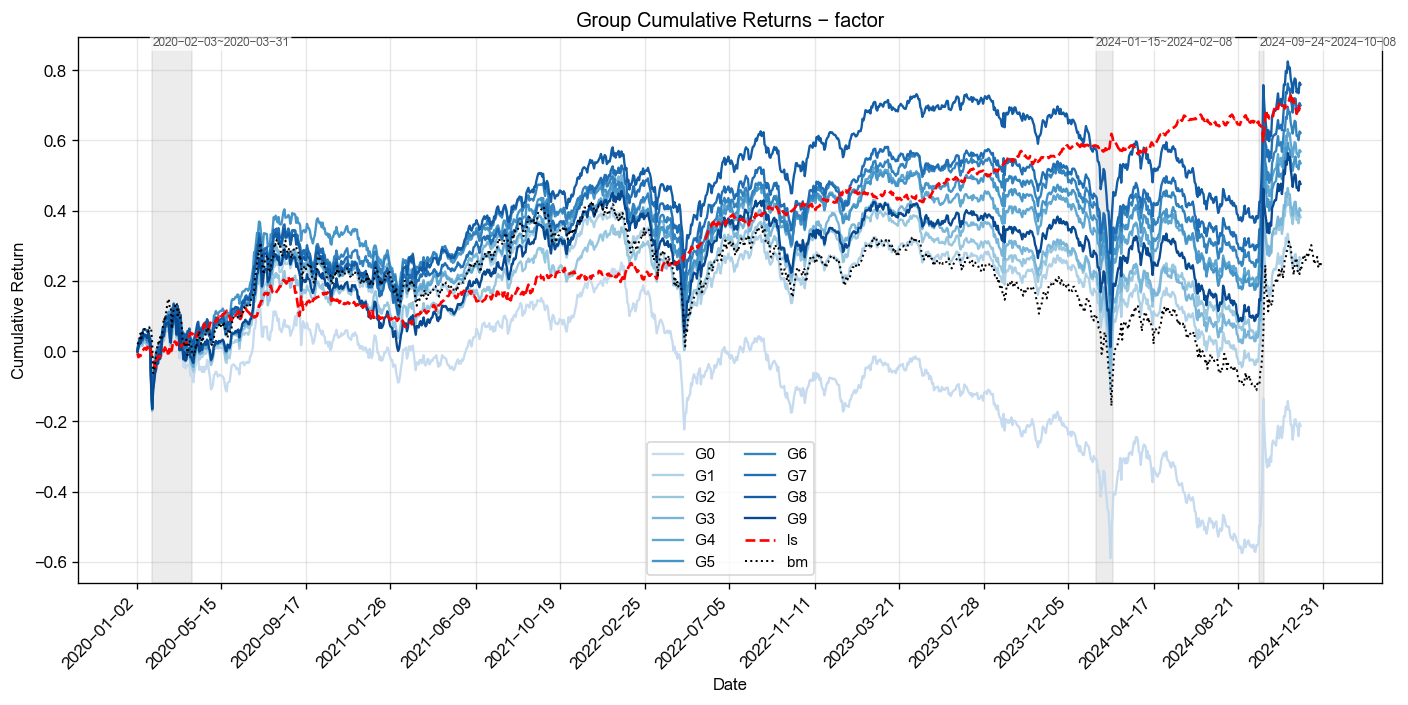
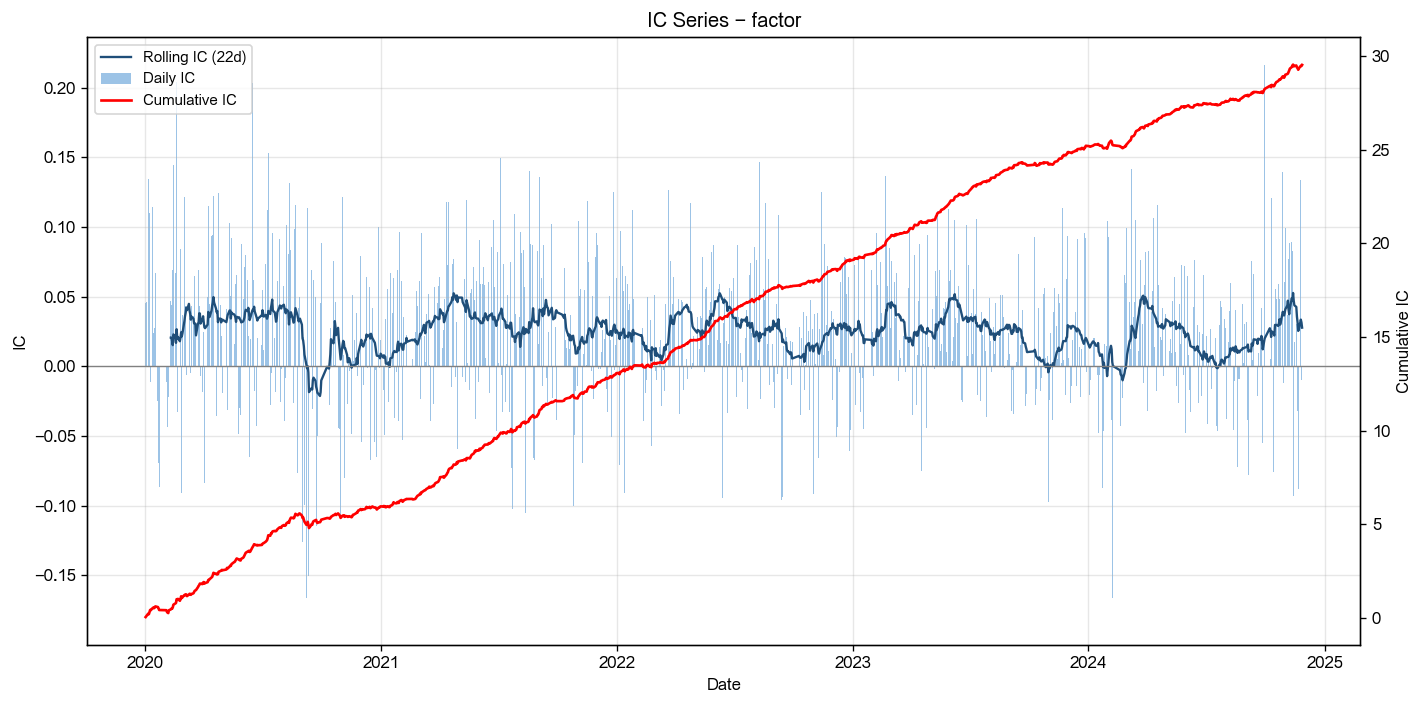
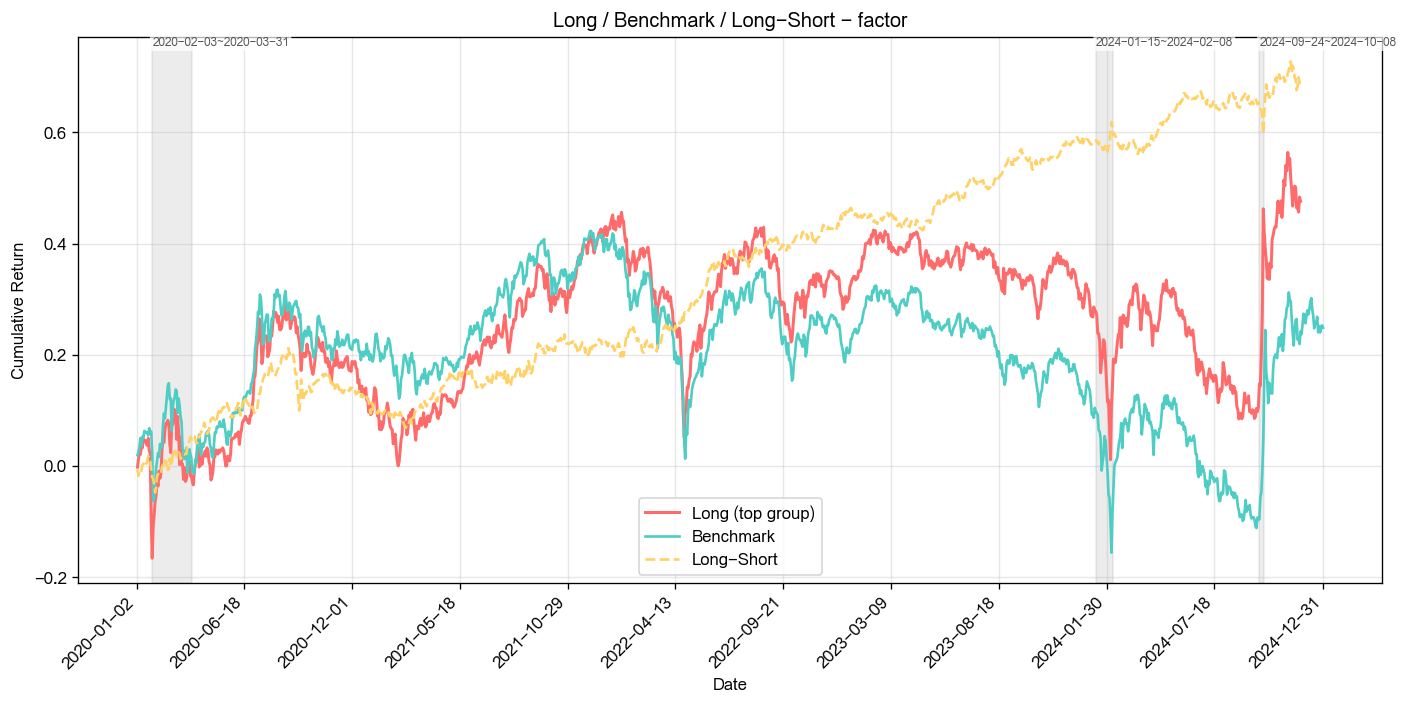
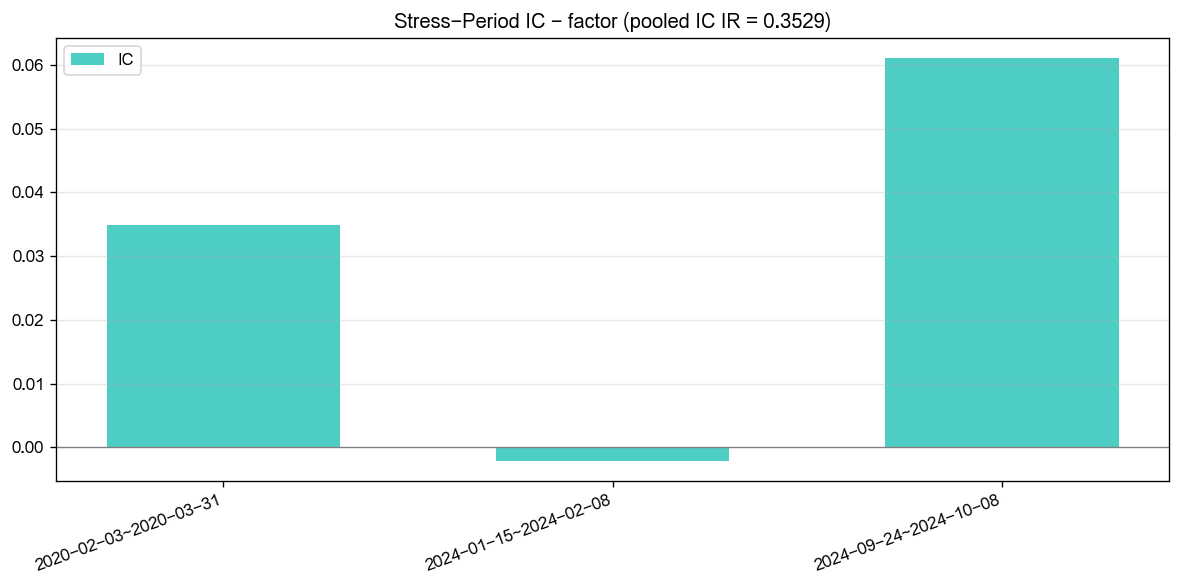
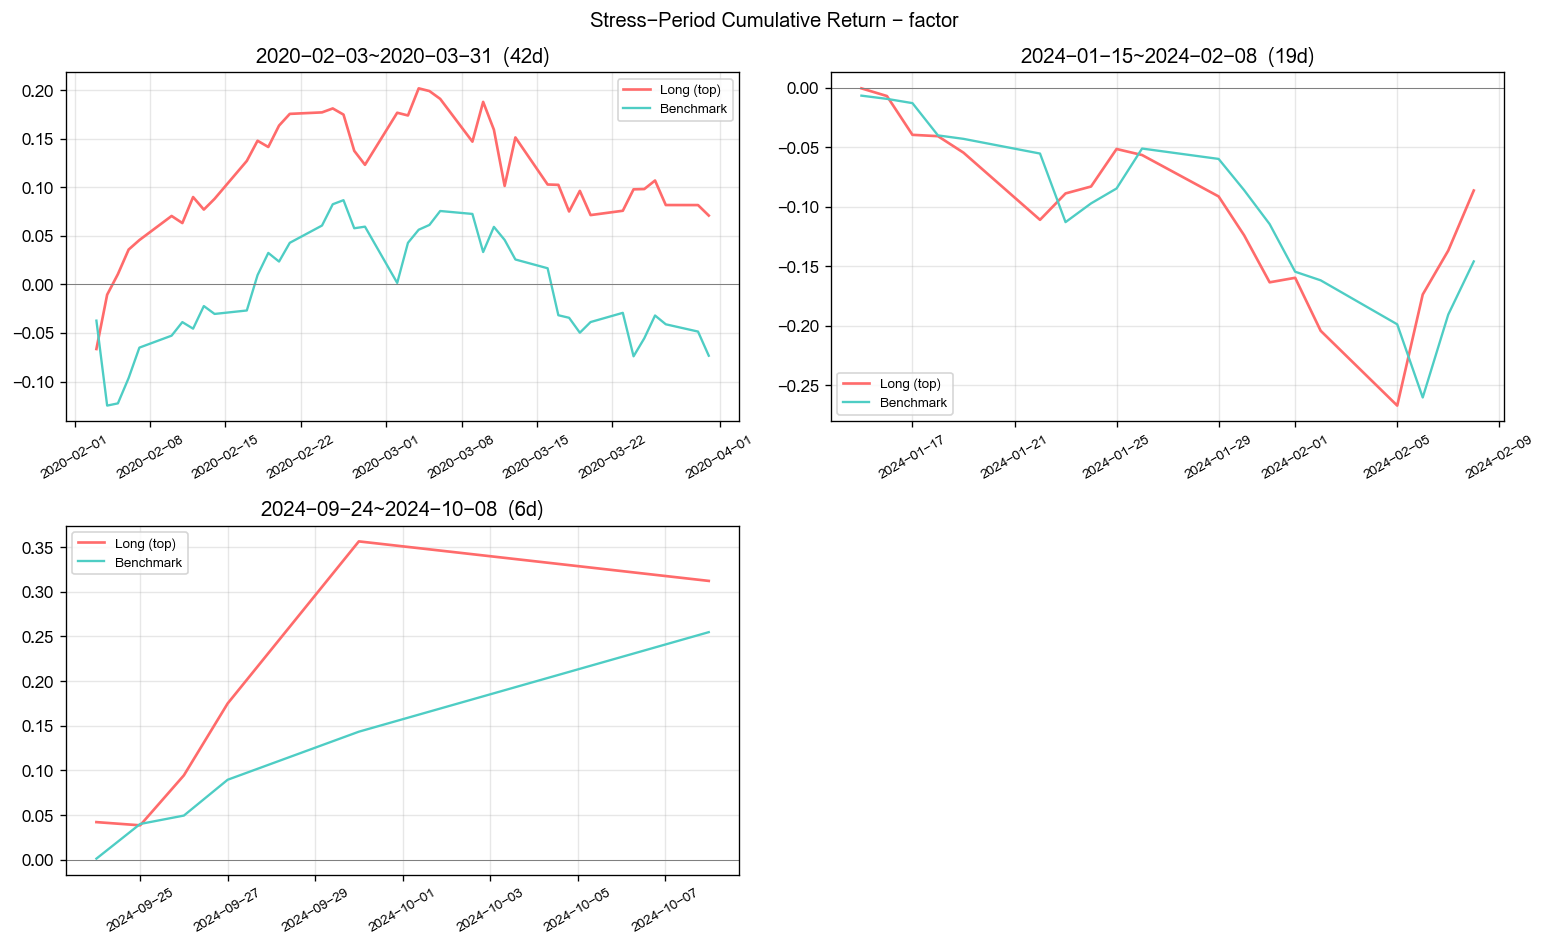

[2026-08-04 17:48:43] [info     ] ========== 因子池回归 ==========
[2026-08-04 17:48:45] [info     ] 加载 T+1 收益数据完成                  end_date=2024-12-31 instrument_count=1913 rows=2121649 start_date=2020-01-02
[2026-08-04 17:48:48] [info     ] 获取收益率数据, 耗时: 4.7011 秒
[2026-08-04 17:48:51] [info     ] 滚动 Elastic Net 拟合, 耗时: 3.4078 秒
[2026-08-04 17:48:51] [info     ] 统计 回归结果, 耗时: 0.0241 秒


#,因子名,ModelScore,mean(|w|),std(|w|),入选率
1,factor,1.8964,0.0182,0.0096,0.9828
2,beta_000300SH_22,1.5009,0.0179,0.0119,1.0000
3,volatility_5,1.4367,0.0158,0.0110,1.0000
4,turn,1.3983,0.0242,0.0173,0.8966
5,momentum_5,1.3908,0.0166,0.0119,0.9655
6,net_active_buy_amount_main,1.3791,0.0182,0.0132,0.9655
7,bias_20,1.3659,0.0275,0.0202,0.8966
8,macd_hist_12_26_9,1.3346,0.0093,0.0069,0.9655
9,cci_14,1.2902,0.0266,0.0206,0.9655
10,gross_profit_rate_ttm,1.2795,0.0115,0.0090,0.9655

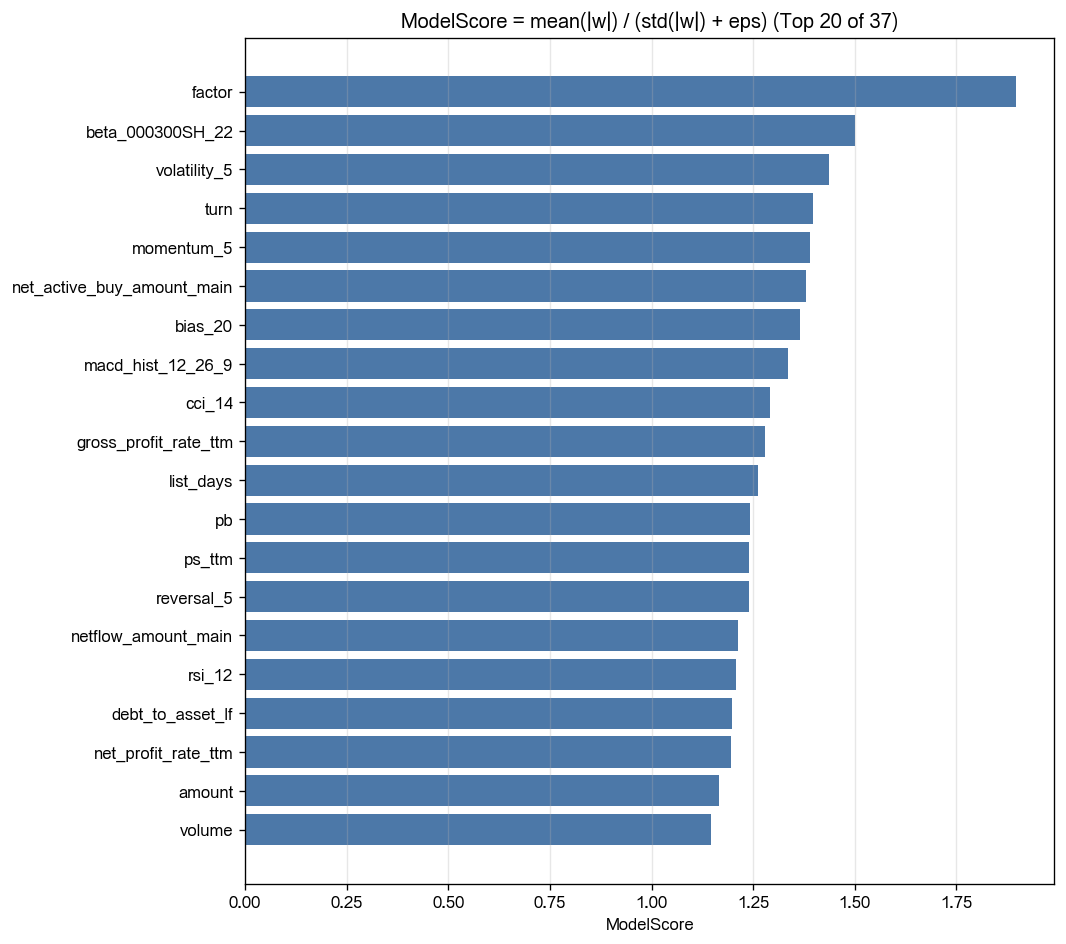
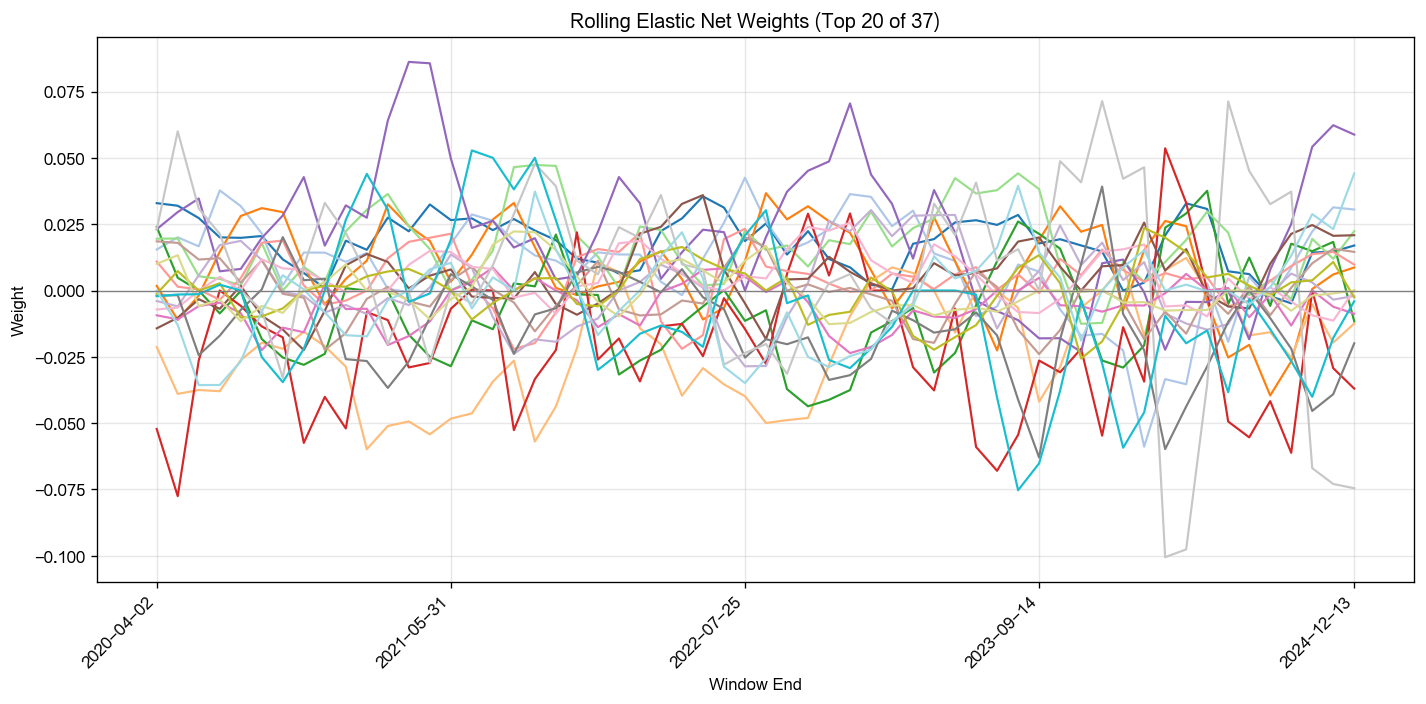
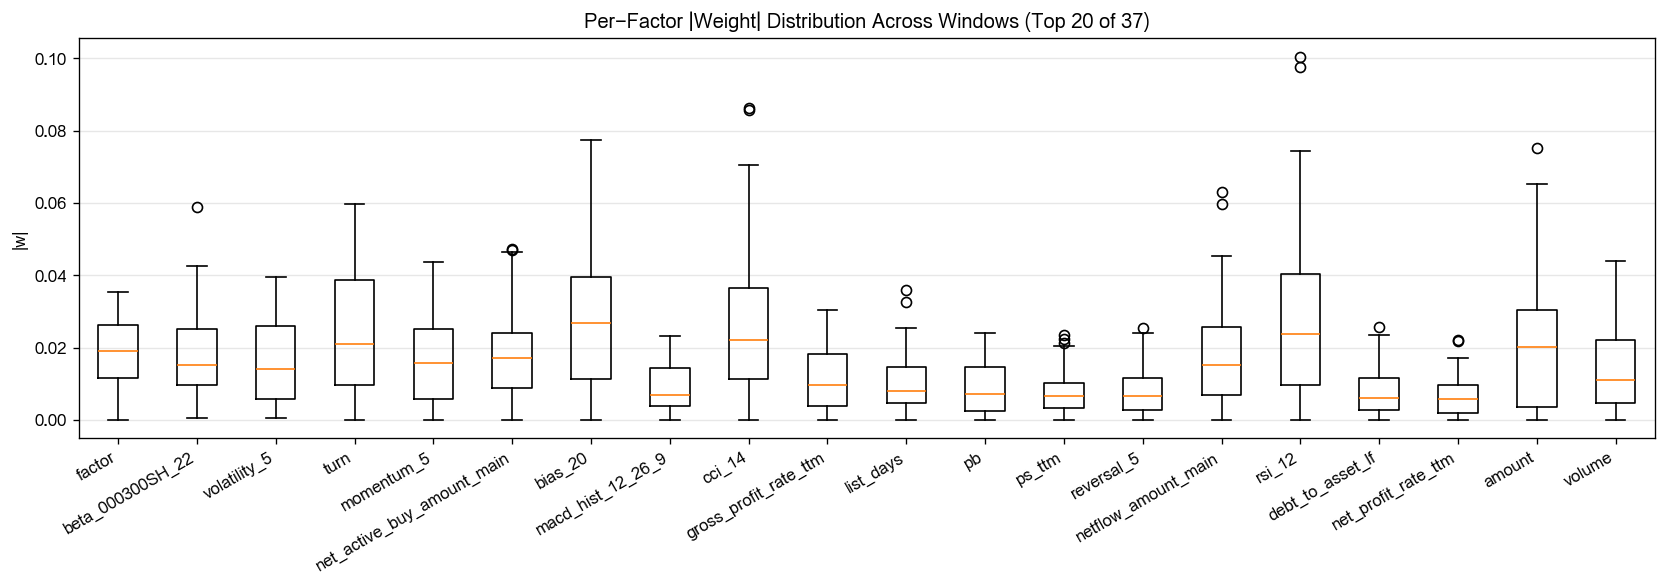
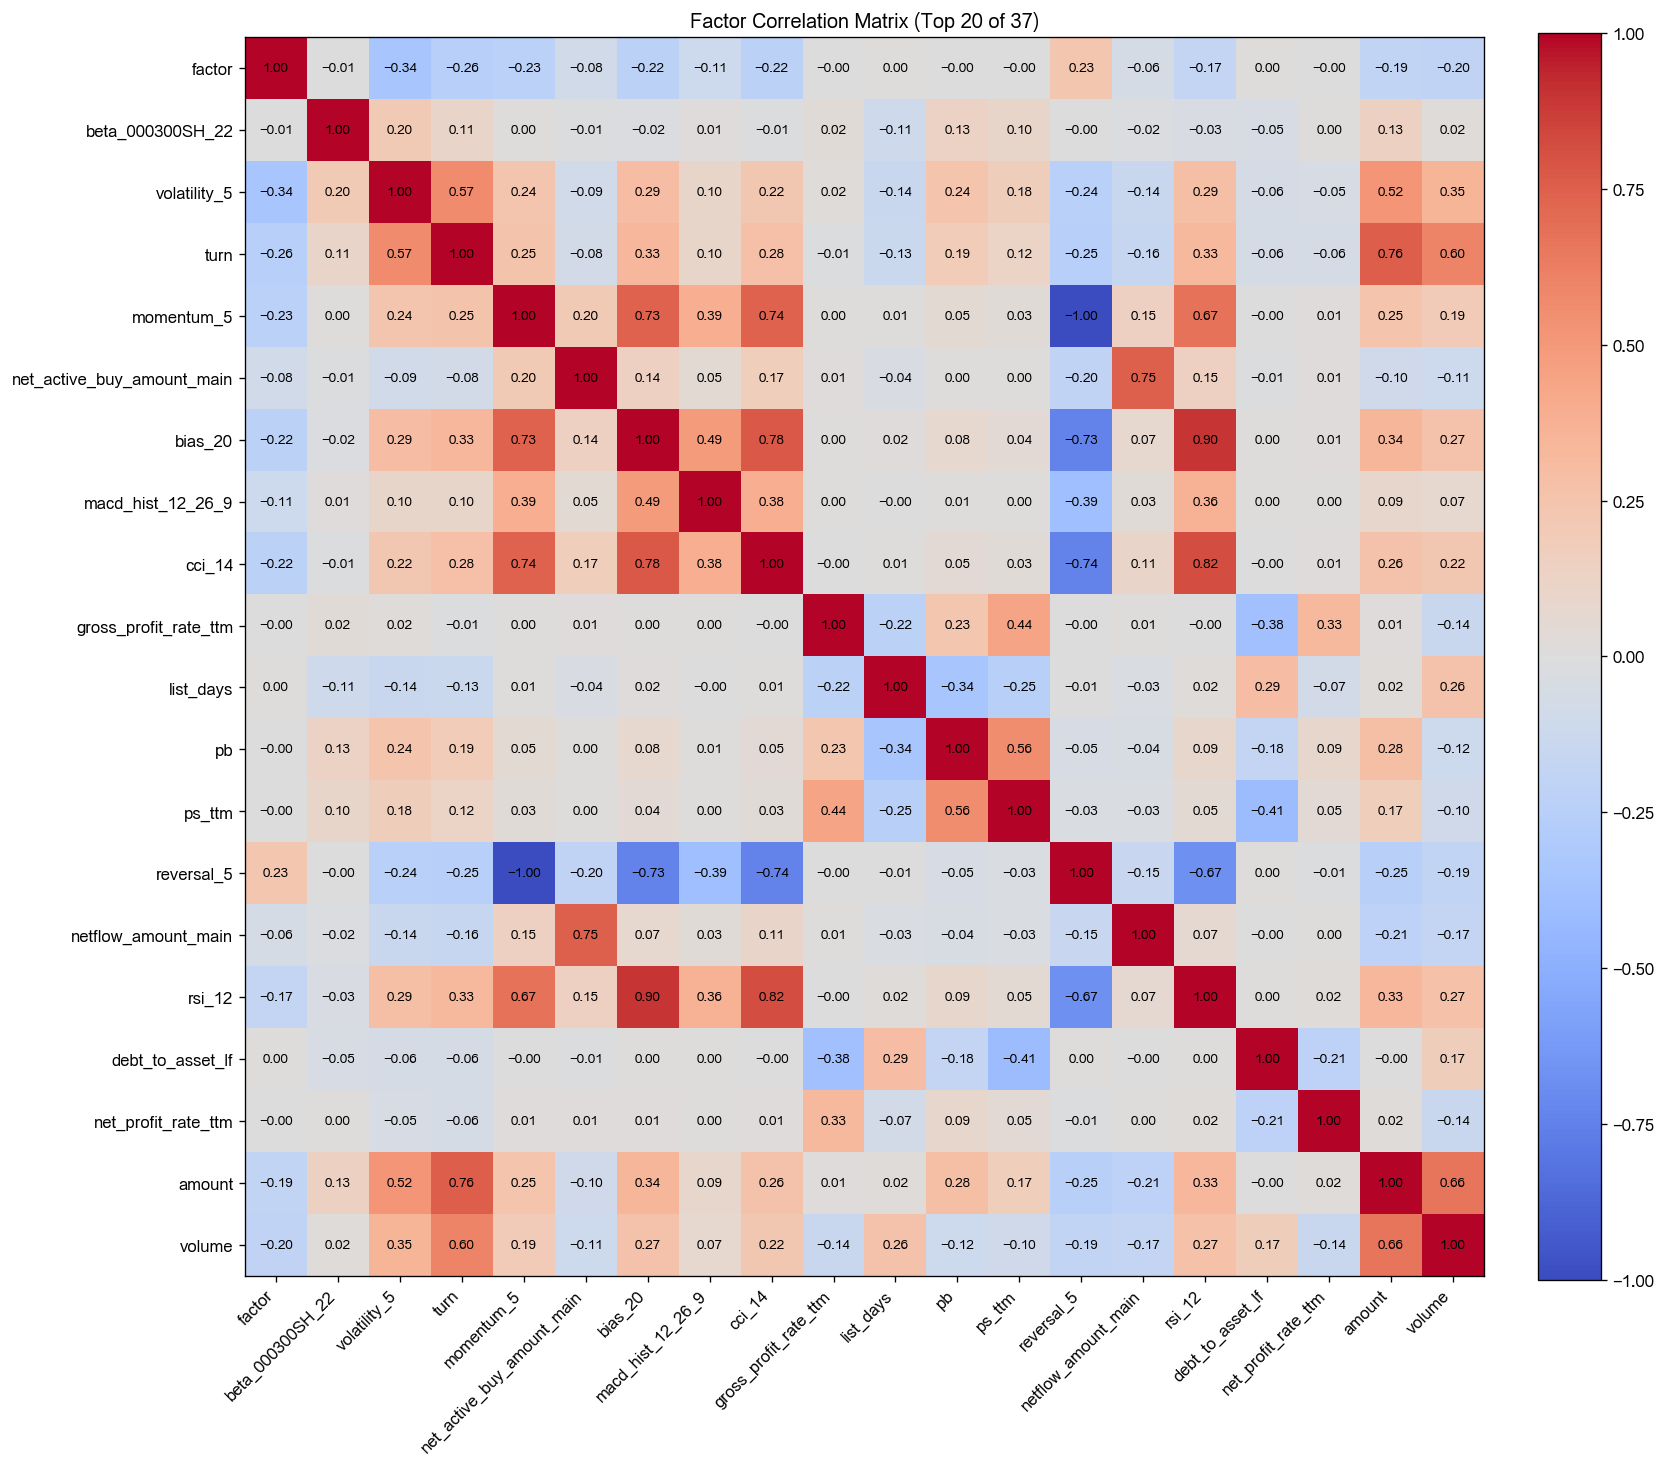

[2026-08-04 17:48:58] [warning  ] 返回的Outputs实例(size=180907857) 大于 64K, 将不会被缓存
[2026-08-04 17:48:58] [info     ] bigalpha_eval.v4 运行完成 [63.350s].


In [4]:
if __name__ == '__main__':
    import dai
    import structlog

    logger = structlog.get_logger()

    # 本地自测: 用全市场分钟表验证因子计算逻辑 (平台上由评测系统注入 datasources, 逻辑名固定 "bar1m")
    datasources = {'bar1m': 'bigalpha_2026_stock_bar1m'}
    start_date = '2020-01-01 00:00:00'
    end_date = '2024-12-31 23:59:59'

    logger.info(f"计算因子，区间：{start_date} ~ {end_date}")
    factor_data = main(datasources, start_date, end_date)

    # 读取平台因子库用于回归评估
    logger.info(f"读取因子库，区间：{start_date} ~ {end_date}")
    factor_pool = dai.query(
        "SELECT * FROM bigalpha_2026_factorlib",
        filters={'date': [start_date, end_date]},
    ).df()

    # 评估系统:
    # process_pools=False 表示不对因子库再做预处理 (bigalpha_2026_factorlib 已处理过)
    # show=True 表示画出评估图表
    from bigmodule import M
    result = M.bigalpha_eval._latest(
        factor_data=factor_data,
        factor_pool=factor_pool,
        process_pools=False,
        show=True,
    )
